## Evaluation of different (vectorizer, model) pairs on 2 datasets

In [137]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents, build_experiments, eval_experiments

import gensim.downloader as api
from gensim.models.fasttext import load_facebook_model

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Movies

In [2]:
from rital_nlp_project.movies.models_config import word2vec_model, fasttext_model, min_df, max_df

texts_movies, classes_movies = load_clean_data("../Dataset/clean/movies_clean.parquet")
# w2v_model = api.load(word2vec_model)
# ft_model = load_facebook_model(f"../models/{fasttext_model}")


In [ ]:
#experiments = build_experiments("movies", models={"word2vec":w2v_model})
experiments = build_experiments("movies", models={"fasttext":ft_model})

In [128]:
#evals = eval_experiments(experiments, texts_movies, classes_movies, eval_pipeline_fn=eval_pipeline_movies, cv=False, split=True)
evals = pd.read_csv("evals/movies_evals.csv")
evals

,pipeline,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,accuracy,precision,recall,f1,roc_auc,train_vocab_size
0,count_char_1gram_count__nb,0.6125,0.608309,0.633,0.619876,0.650480,0.6500,0.647059,0.660,0.653465,0.683025,33.0
1,count_char_1gram_count__logreg,0.6125,0.610182,0.623,0.616235,0.647780,0.6000,0.605263,0.575,0.589744,0.641400,33.0
2,count_char_1gram_count__svm,0.6210,0.620103,0.625,0.622248,0.663840,0.6475,0.656085,0.620,0.637532,0.666550,33.0
3,count_char_4gram_count__nb,0.8160,0.831759,0.793,0.811321,0.889500,0.8250,0.825000,0.825,0.825000,0.902275,10000.0
4,count_char_4gram_count__logreg,0.8160,0.819361,0.811,0.815092,0.896505,0.8150,0.791667,0.855,0.822115,0.912875,10000.0
5,count_char_4gram_count__svm,0.8460,0.843894,0.849,0.846399,0.916045,0.8500,0.818182,0.900,0.857143,0.919325,10000.0
6,count_word_1gram_count__nb,0.8100,0.846978,0.757,0.798982,0.901690,0.8225,0.844920,0.790,0.816537,0.906125,10000.0
7,count_word_1gram_count__logreg,0.8305,0.823258,0.842,0.832492,0.902525,0.8325,0.818182,0.855,0.836186,0.911350,10000.0
8,count_word_1gram_count__svm,0.8415,0.840076,0.844,0.841966,0.920420,0.8450,0.831731,0.865,0.848039,0.923925,10000.0
9,count_word_13gram_count__nb,0.8180,0.843611,0.781,0.810621,0.902340,0.8175,0.825641,0.805,0.815190,0.907050,10000.0


In [129]:
# plt.figure(figsize=(8, 10))
# cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
# mask = evals["pipeline"].str.contains("word2vec|fasttext", na=False)
# sns.heatmap(evals[~mask].set_index("pipeline")[cols], annot=True, cmap="viridis")
# plt.title("Cross-validation (5-fold)")
# plt.xticks(rotation=45)
# plt.tight_layout()

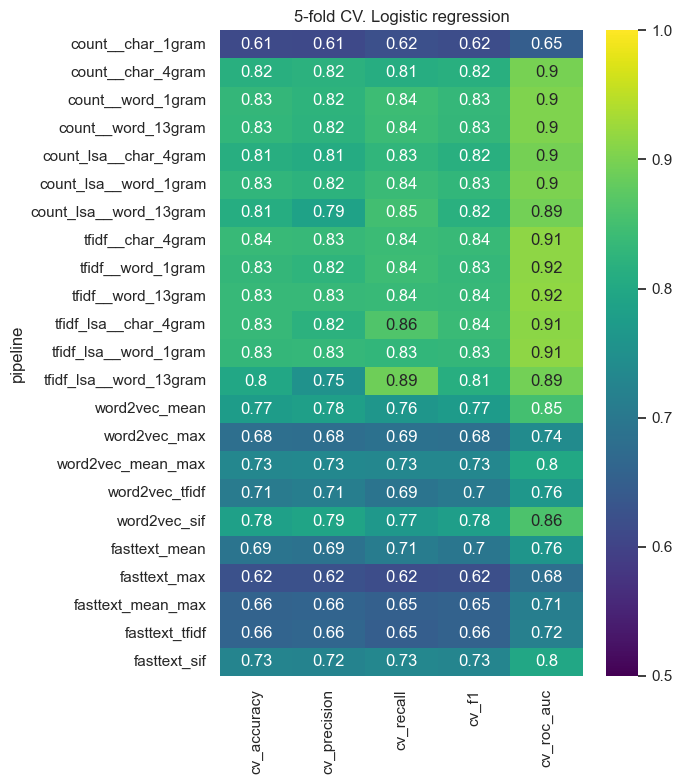

In [130]:
rename_map = {
    "count_char_1gram_count__nb": "count__char_1gram__nb",
    "count_char_1gram_count__logreg": "count__char_1gram__logreg",
    "count_char_1gram_count__svm": "count__char_1gram__svm",

    "count_char_4gram_count__nb": "count__char_4gram__nb",
    "count_char_4gram_count__logreg": "count__char_4gram__logreg",
    "count_char_4gram_count__svm": "count__char_4gram__svm",

    "count_word_1gram_count__nb": "count__word_1gram__nb",
    "count_word_1gram_count__logreg": "count__word_1gram__logreg",
    "count_word_1gram_count__svm": "count__word_1gram__svm",

    "count_word_13gram_count__nb": "count__word_13gram__nb",
    "count_word_13gram_count__logreg": "count__word_13gram__logreg",
    "count_word_13gram_count__svm": "count__word_13gram__svm",

    "count_lsa_char_4gram_count_lsa__logreg": "count_lsa__char_4gram__logreg",
    "count_lsa_char_4gram_count_lsa__svm": "count_lsa__char_4gram__svm",
    "count_lsa_word_1gram_count_lsa__logreg": "count_lsa__word_1gram__logreg",
    "count_lsa_word_1gram_count_lsa__svm": "count_lsa__word_1gram__svm",
    "count_lsa_word_13gram_count_lsa__logreg": "count_lsa__word_13gram__logreg",
    "count_lsa_word_13gram_count_lsa__svm": "count_lsa__word_13gram__svm",

    "tfidf_char_4gram_tfidf__logreg": "tfidf__char_4gram__logreg",
    "tfidf_char_4gram_tfidf__svm": "tfidf__char_4gram__svm",
    "tfidf_word_1gram_tfidf__logreg": "tfidf__word_1gram__logreg",
    "tfidf_word_1gram_tfidf__svm": "tfidf__word_1gram__svm",
    "tfidf_word_13gram_tfidf__logreg": "tfidf__word_13gram__logreg",
    "tfidf_word_13gram_tfidf__svm": "tfidf__word_13gram__svm",

    "tfidf_lsa_char_4gram_tfidf_lsa__logreg": "tfidf_lsa__char_4gram__logreg",
    "tfidf_lsa_char_4gram_tfidf_lsa__svm": "tfidf_lsa__char_4gram__svm",
    "tfidf_lsa_word_1gram_tfidf_lsa__logreg": "tfidf_lsa__word_1gram__logreg",
    "tfidf_lsa_word_1gram_tfidf_lsa__svm": "tfidf_lsa__word_1gram__svm",
    "tfidf_lsa_word_13gram_tfidf_lsa__logreg": "tfidf_lsa__word_13gram__logreg",
    "tfidf_lsa_word_13gram_tfidf_lsa__svm": "tfidf_lsa__word_13gram__svm",
}

order_map = {
    "count__char_1gram__nb": 0,
    "count__char_1gram__logreg": 1,
    "count__char_1gram__svm": 2,

    "count__char_4gram__nb": 3,
    "count__char_4gram__logreg": 4,
    "count__char_4gram__svm": 5,

    "count__word_1gram__nb": 6,
    "count__word_1gram__logreg": 7,
    "count__word_1gram__svm": 8,

    "count__word_13gram__nb": 9,
    "count__word_13gram__logreg": 10,
    "count__word_13gram__svm": 11,

    "count_lsa__char_4gram__logreg": 12,
    "count_lsa__char_4gram__svm": 13,
    "count_lsa__word_1gram__logreg": 14,
    "count_lsa__word_1gram__svm": 15,
    "count_lsa__word_13gram__logreg": 16,
    "count_lsa__word_13gram__svm": 17,

    "tfidf__char_4gram__logreg": 18,
    "tfidf__char_4gram__svm": 19,
    "tfidf__word_1gram__logreg": 20,
    "tfidf__word_1gram__svm": 21,
    "tfidf__word_13gram__logreg": 22,
    "tfidf__word_13gram__svm": 23,

    "tfidf_lsa__char_4gram__logreg": 24,
    "tfidf_lsa__char_4gram__svm": 25,
    "tfidf_lsa__word_1gram__logreg": 26,
    "tfidf_lsa__word_1gram__svm": 27,
    "tfidf_lsa__word_13gram__logreg": 28,
    "tfidf_lsa__word_13gram__svm": 29,

    "word2vec_mean__logreg": 30,
    "word2vec_mean__svm": 31,
    "word2vec_max__logreg": 32,
    "word2vec_max__svm": 33,
    "word2vec_mean_max__logreg": 34,
    "word2vec_mean_max__svm": 35,
    "word2vec_tfidf__logreg": 36,
    "word2vec_tfidf__svm": 37,
    "word2vec_sif__logreg": 38,
    "word2vec_sif__svm": 39,
    "fasttext_mean__logreg": 40,
    "fasttext_mean__svm": 41,
    "fasttext_max__logreg": 42,
    "fasttext_max__svm": 43,
    "fasttext_mean_max__logreg": 44,
    "fasttext_mean_max__svm": 45,
    "fasttext_tfidf__logreg": 46,
    "fasttext_tfidf__svm": 47,
    "fasttext_sif__logreg": 48,
    "fasttext_sif__svm": 49,
}

evals_pretty = evals.copy()
evals_pretty["pipeline"] = evals["pipeline"].replace(rename_map)
evals_pretty["order"] = evals_pretty["pipeline"].map(order_map)
evals_pretty = evals_pretty.sort_values("order").drop(columns="order")

cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7, 8))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("logreg")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("5-fold CV. Logistic regression")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_cv_log_reg.pdf", bbox_inches="tight")

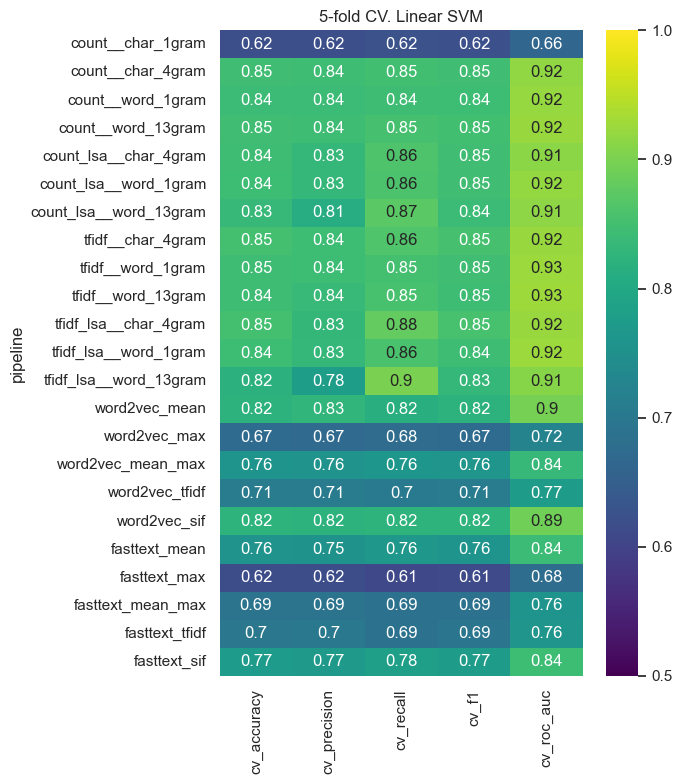

In [131]:
fig=plt.figure(figsize=(7, 8))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("svm")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__svm", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("5-fold CV. Linear SVM")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_cv_linear_svm.pdf", bbox_inches="tight")

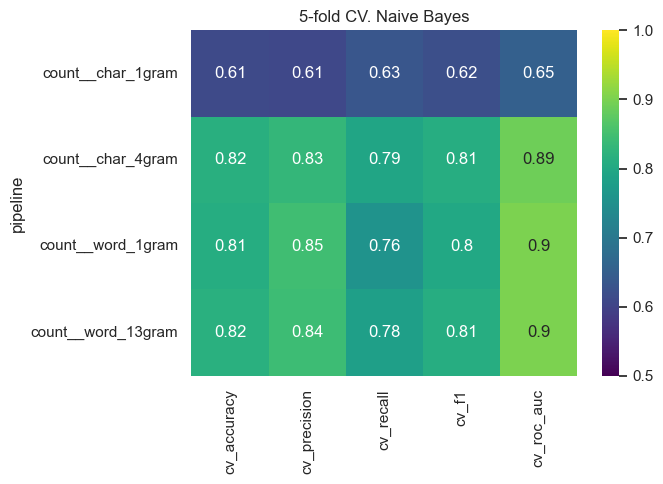

In [132]:
fig=plt.figure(figsize=(7, 5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__nb")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__nb", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("5-fold CV. Naive Bayes")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_cv_nb.pdf", bbox_inches="tight")

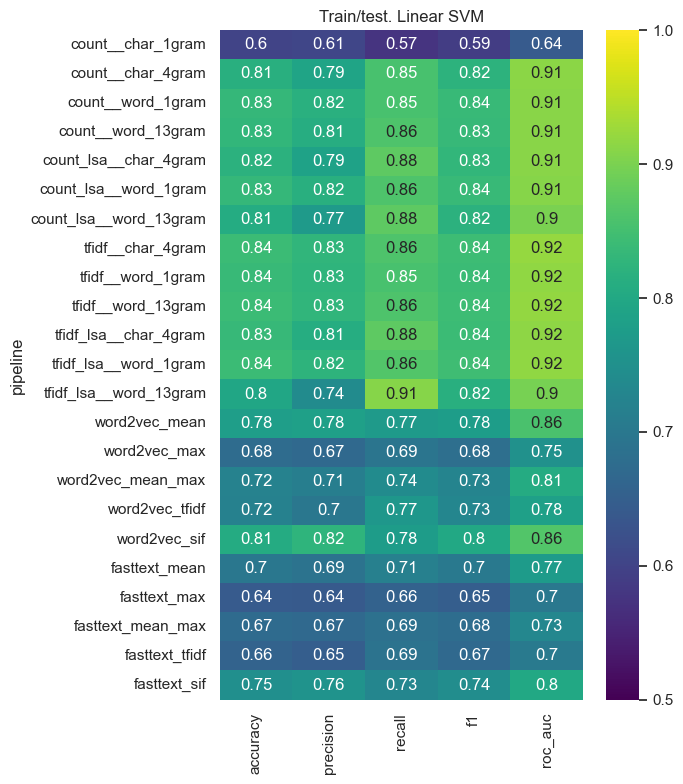

In [133]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7, 8))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("logreg")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("Train/test. Linear SVM")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_tt_log_reg.pdf", bbox_inches="tight")

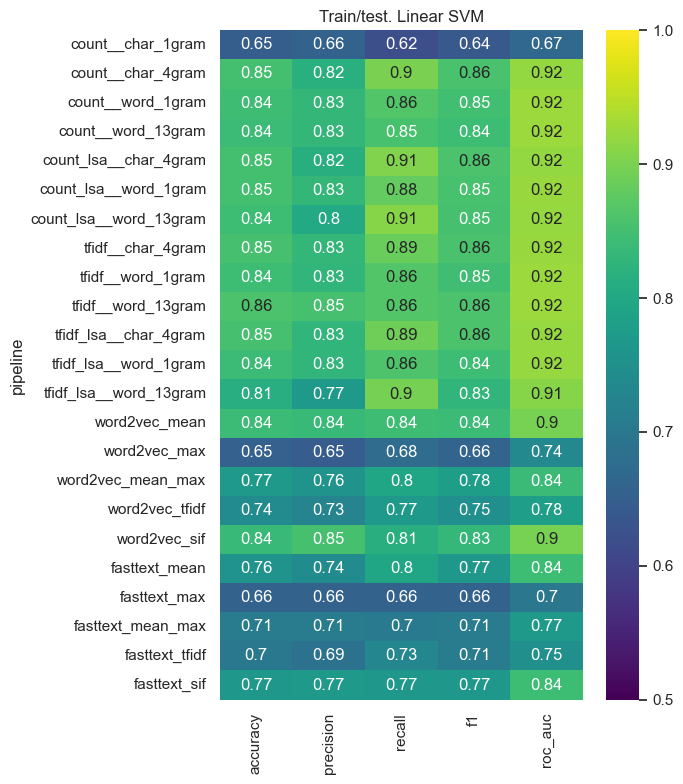

In [134]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7, 8))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("svm")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__svm", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("Train/test. Linear SVM")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_tt_linear_svm.pdf", bbox_inches="tight")

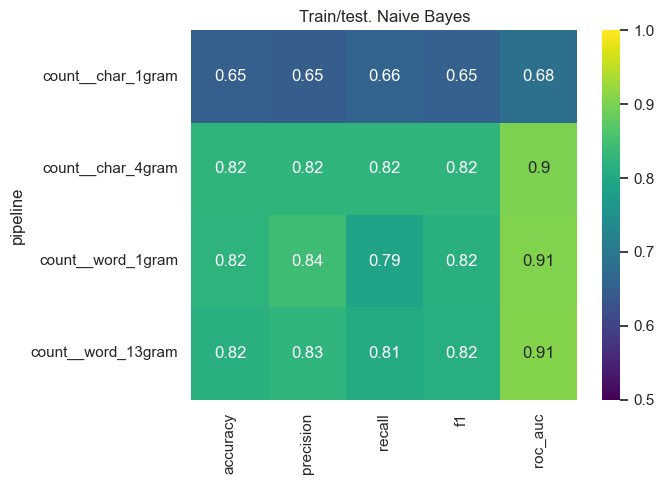

In [135]:
fig=plt.figure(figsize=(7, 5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__nb")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__nb", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.5, vmax=1.)
plt.title("Train/test. Naive Bayes")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/movies_tt_nb.pdf", bbox_inches="tight")

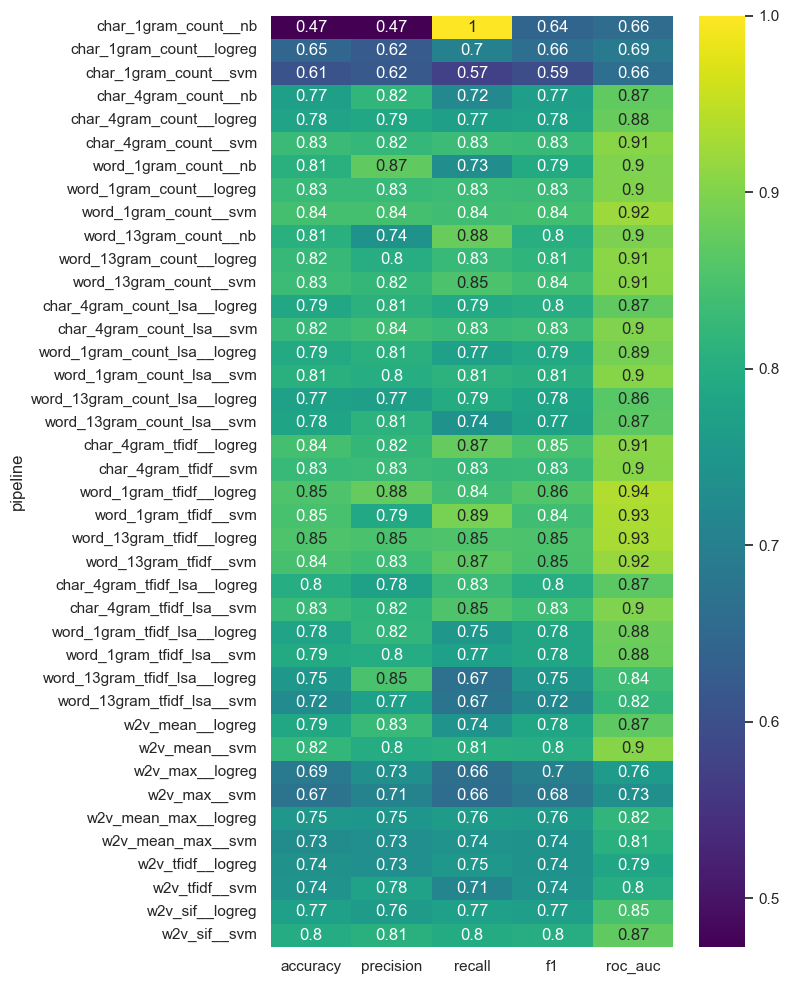

In [ ]:
plt.figure(figsize=(8, 10))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.tight_layout()

In [ ]:
# plt.figure(figsize=(8, 10))
# cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
# sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
# plt.title("Cross-validation (5-fold)")
# plt.tight_layout()

### Presidents

In [ ]:
from rital_nlp_project.presidents.models_config import fasttext_model

texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean.parquet")
#ft_model = load_facebook_model(f"../models/{fasttext_model}")

In [139]:
evals = pd.read_csv("evals/pres_evals.csv")

In [ ]:
order_map = {
    # ---------------- COUNT + CHAR ----------------
    "count_char_1gram_count__nb": 0,
    "count_char_1gram_count__logreg_2_to_1": 1,
    "count_char_1gram_count__logreg_balanced": 2,

    "count_char_4gram_count__nb": 3,
    "count_char_4gram_count__logreg_2_to_1": 4,
    "count_char_4gram_count__logreg_balanced": 5,

    # ---------------- COUNT + WORD ----------------
    "count_word_1gram_count__nb": 6,
    "count_word_1gram_count__logreg_2_to_1": 7,
    "count_word_1gram_count__logreg_balanced": 8,

    "count_word_13gram_count__nb": 9,
    "count_word_13gram_count__logreg_2_to_1": 10,
    "count_word_13gram_count__logreg_balanced": 11,

    # ---------------- TF-IDF + CHAR ----------------
    "tfidf_char_4gram_tfidf__logreg_2_to_1": 12,
    "tfidf_char_4gram_tfidf__logreg_balanced": 13,

    # ---------------- TF-IDF + WORD ----------------
    "tfidf_word_1gram_tfidf__logreg_2_to_1": 14,
    "tfidf_word_1gram_tfidf__logreg_balanced": 15,

    "tfidf_word_13gram_tfidf__logreg_2_to_1": 16,
    "tfidf_word_13gram_tfidf__logreg_balanced": 17,

    # ---------------- FASTTEXT ----------------
    "fasttext_mean__logreg_2_to_1": 18,
    "fasttext_mean__logreg_balanced": 19,

    "fasttext_max__logreg_2_to_1": 20,
    "fasttext_max__logreg_balanced": 21,

    "fasttext_mean_max__logreg_2_to_1": 22,
    "fasttext_mean_max__logreg_balanced": 23,

    "fasttext_tfidf__logreg_2_to_1": 24,
    "fasttext_tfidf__logreg_balanced": 25,

    "fasttext_sif__logreg_2_to_1": 26,
    "fasttext_sif__logreg_balanced": 27,
}

evals_pretty = evals.copy()
evals_pretty["order"] = evals_pretty["pipeline"].map(order_map)
evals_pretty = evals_pretty.sort_values("order").drop(columns="order")

In [151]:
evals_pretty.columns

Index(['pipeline', 'cv_accuracy', 'cv_f1', 'cv_recall', 'cv_precision',
       'cv_roc_auc', 'cv_pr_auc', 'accuracy', 'f1', 'recall', 'precision',
       'roc_auc', 'pr_auc', 'train_vocab_size'],
      dtype='str')

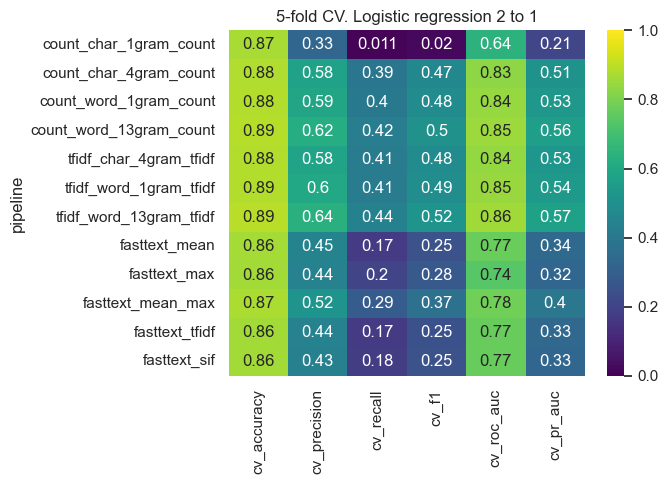

In [161]:
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc', 'cv_pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__logreg_2_to_1")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg_2_to_1", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.0, vmax=1.)
plt.title("5-fold CV. Logistic regression 2 to 1")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_cv_log_reg_2_to_1.pdf", bbox_inches="tight")

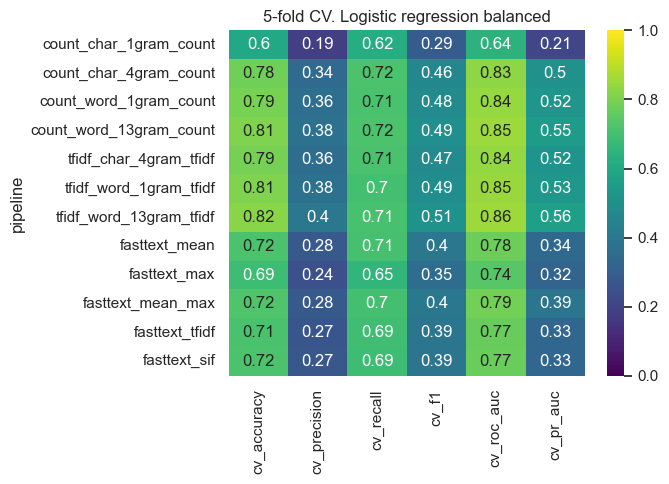

In [162]:
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc', 'cv_pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__logreg_balanced")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg_balanced", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.0, vmax=1.)
plt.title("5-fold CV. Logistic regression balanced")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_cv_log_reg_balanced.pdf", bbox_inches="tight")

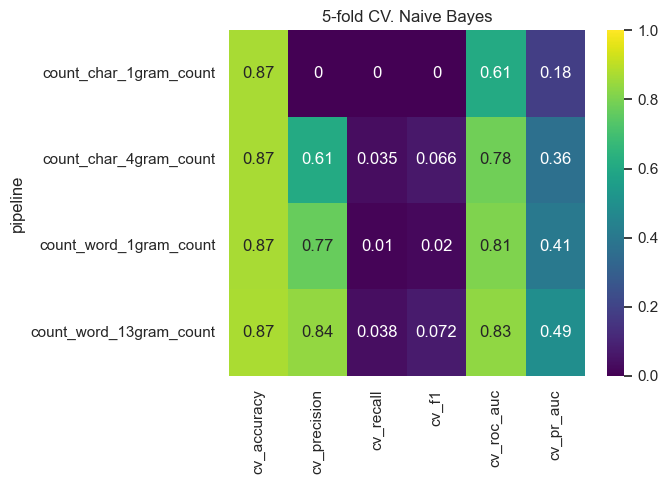

In [163]:
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc', 'cv_pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__nb")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__nb", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.0, vmax=1.)
plt.title("5-fold CV. Naive Bayes")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_cv_nb.pdf", bbox_inches="tight")

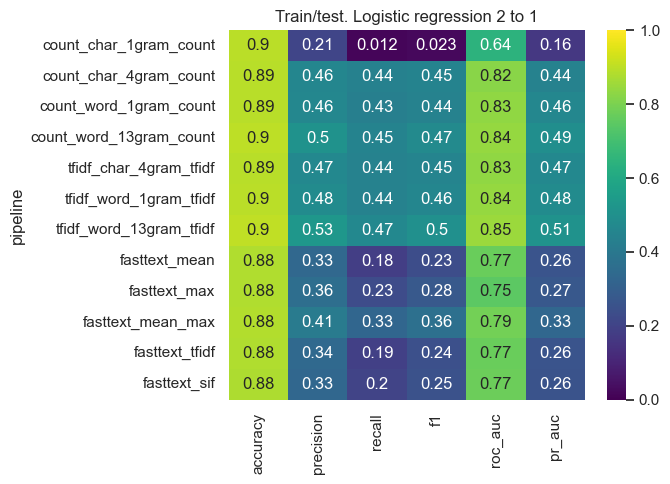

In [168]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__logreg_2_to_1")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg_2_to_1", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.0, vmax=1.)
plt.title("Train/test. Logistic regression 2 to 1")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_tt_log_reg_2_to_1.pdf", bbox_inches="tight")

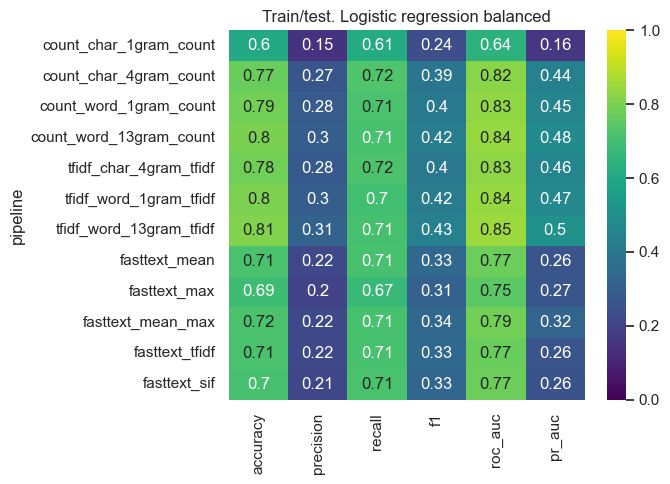

In [169]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__logreg_balanced")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__logreg_balanced", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0.0, vmax=1.)
plt.title("Train/test. Logistic regression balanced")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_tt_log_reg_balanced.pdf", bbox_inches="tight")

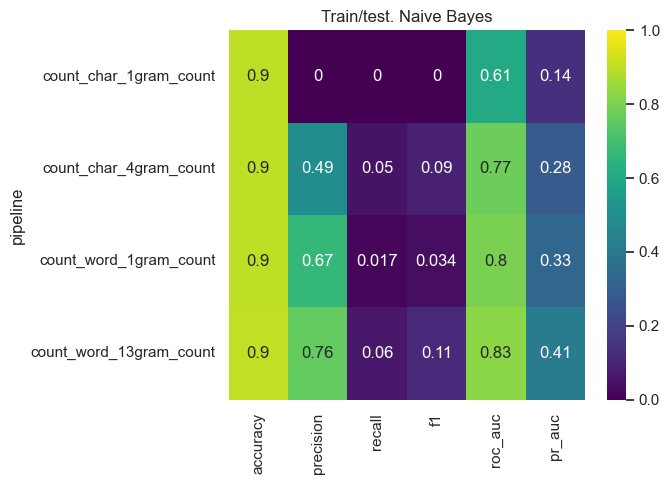

In [170]:
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
#cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig=plt.figure(figsize=(7,5))
heatmap = evals_pretty[evals_pretty["pipeline"].str.contains("__nb")]
heatmap["pipeline"] = heatmap["pipeline"].str.replace("__nb", "", regex=False)
heatmap = heatmap.set_index("pipeline")[cols]
sns.heatmap(heatmap, annot=True, cmap="viridis", vmin=0., vmax=1.)
plt.title("Train/test. Naive Bayes")
plt.xticks(rotation=90)
plt.tight_layout()
fig.savefig("plots/pres_tt_nb.pdf", bbox_inches="tight")

In [120]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("vect",TfidfVectorizer(min_df=5, max_df=0.5)),
    ("classifier",LogisticRegression(class_weight={-1:2, 1:1}))
])
res = eval_pipeline_presidents(pipe, texts_pres, classes_pres, cv=True, split=True)
res

Pipeline(steps=[('vect', TfidfVectorizer(max_df=0.5, min_df=5)),
                ('classifier', LogisticRegression(class_weight={-1: 2, 1: 1}))])


{'cv_accuracy': 0.8861755136069538,
 'cv_f1': 0.9359195271572169,
 'cv_recall': 0.9566245740629385,
 'cv_precision': 0.9161035215730688,
 'cv_roc_auc': 0.846009420590996,
 'train_train_time': 0.35152411460876465,
 'test_infer_time': 0.04724001884460449,
 'accuracy': 0.8955847774971697,
 'f1': 0.9421527476238722,
 'recall': 0.9461240310077519,
 'precision': 0.9382146632074565,
 'roc_auc': 0.8411215564531718,
 'train_vocab_size': 6601}

In [4]:
#experiments = build_experiments(models={"fasttext":ft_model})
experiments = build_experiments("presidents")

In [11]:
evals = eval_experiments(experiments, texts_pres, classes_pres, eval_pipeline_fn=eval_pipeline_presidents, cv=True, split=True)

Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', MultinomialNB())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LogisticRegression())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LinearSVC())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf',
                 SmoothedProbaClassifier(base_estimator=MultinomialNB(),
                                         sigma=1))])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_ran

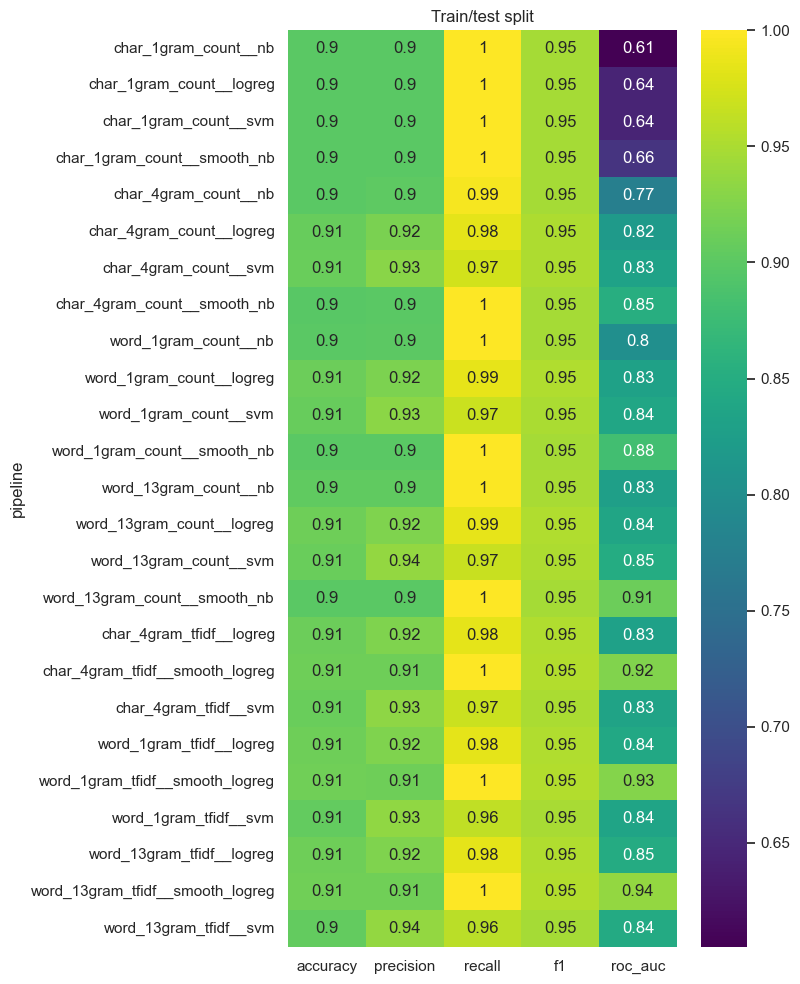

In [12]:
plt.figure(figsize=(8, 10))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.tight_layout()

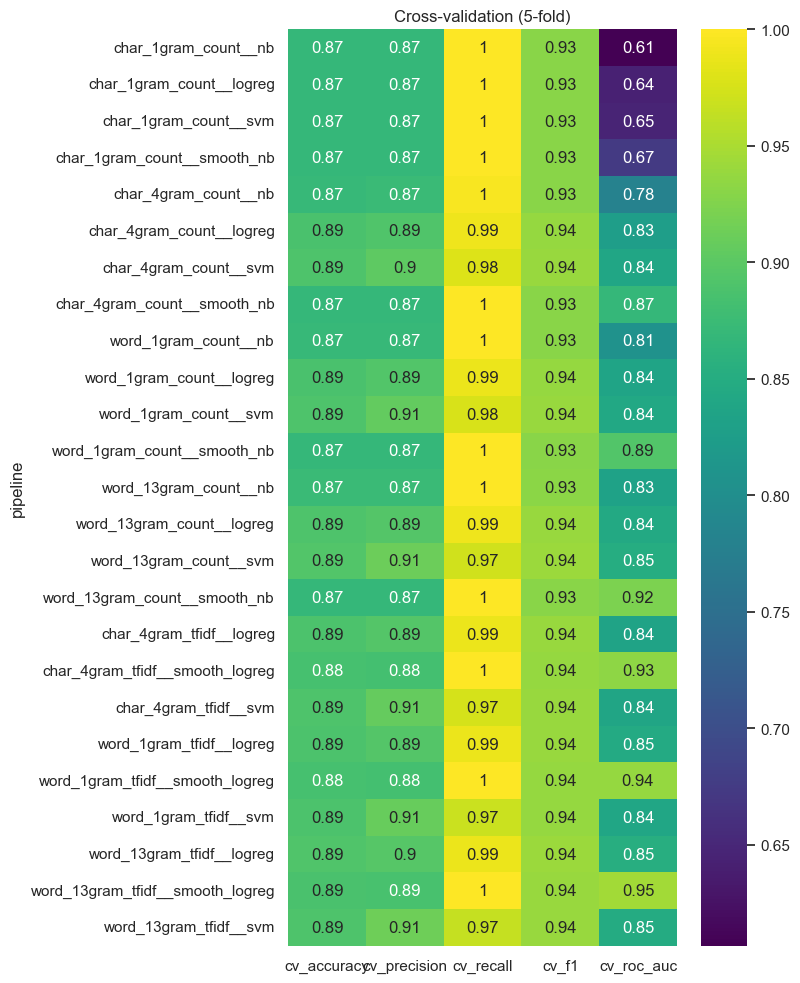

In [14]:
plt.figure(figsize=(8, 10))
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Cross-validation (5-fold)")
plt.tight_layout()